# 03 — Target analysis

**Child Mind Institute — Problematic Internet Use**

Цель ноутбука — отдельно разобрать целевую переменную `sii` до анализа остальных признаков.

Рассматриваем:

- доступность target;
- распределение классов и class imbalance;
- ordinal-структуру `sii`;
- точную связь `PCIAT-PCIAT_Total → sii`;
- зависимость распределения target от возраста и пола.



## 1. Imports and data loading

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

TARGET = "sii"
ID_COL = "id"
AGE_COL = "Basic_Demos-Age"
SEX_COL = "Basic_Demos-Sex"
PCIAT_TOTAL = "PCIAT-PCIAT_Total"


In [21]:
# Работает при запуске Jupyter как из корня проекта, так и из project/notebooks/
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
DATA_DICT_PATH = DATA_DIR / "data_dictionary.csv"

for path in [TRAIN_PATH, TEST_PATH, DATA_DICT_PATH]:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path.resolve()}")

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
data_dict = pd.read_csv(DATA_DICT_PATH)

labeled = train.loc[train[TARGET].notna()].copy()
unlabeled = train.loc[train[TARGET].isna()].copy()

print("Train:", train.shape)
print("Labeled:", labeled.shape)
print("Unlabeled:", unlabeled.shape)


Train: (3960, 82)
Labeled: (2736, 82)
Unlabeled: (1224, 82)


## 2. Target availability

Для supervised-задачи используем только строки с известным `sii`.

В исходном train target отсутствует у заметной части участников, поэтому количество строк в CSV и размер supervised subset — разные величины.


In [22]:
target_availability = pd.DataFrame({
    "group": ["sii available", "sii missing"],
    "count": [
        train[TARGET].notna().sum(),
        train[TARGET].isna().sum(),
    ],
    "percent": [
        train[TARGET].notna().mean() * 100,
        train[TARGET].isna().mean() * 100,
    ],
})

display(target_availability.round(2))


,group,count,percent
0,sii available,2736,69.09
1,sii missing,1224,30.91


In [23]:
# Проверяем связь отсутствия target с отсутствием PCIAT total
availability_check = pd.crosstab(
    train[PCIAT_TOTAL].notna(),
    train[TARGET].notna(),
)
availability_check.index = ["PCIAT total missing", "PCIAT total available"]
availability_check.columns = ["sii missing", "sii available"]

display(availability_check)

assert (
    train[PCIAT_TOTAL].notna().equals(train[TARGET].notna())
), "Unexpected mismatch between PCIAT total and SII availability"


,sii missing,sii available
PCIAT total missing,1224,0
PCIAT total available,0,2736


### Observation

В этом train `sii` доступен **ровно тогда**, когда доступен `PCIAT-PCIAT_Total`.

Это ожидаемо: `sii` является severity category, полученной из суммарного PCIAT score. Поэтому отсутствие PCIAT автоматически означает отсутствие target.


## 3. Class distribution

In [24]:
target_distribution = (
    labeled[TARGET]
    .value_counts()
    .sort_index()
    .rename("count")
    .to_frame()
)

target_distribution["percent"] = (
    target_distribution["count"] / len(labeled) * 100
)

target_distribution.index = target_distribution.index.astype(int)
target_distribution.index.name = TARGET

display(target_distribution.round(2))


,count,percent
sii,,
0,1594,58.26
1,730,26.68
2,378,13.82
3,34,1.24


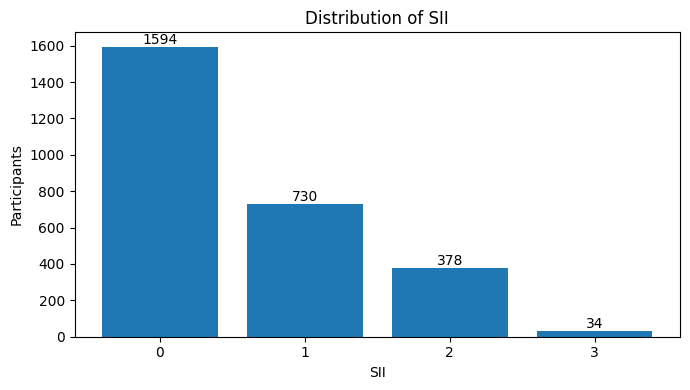

In [25]:
plt.figure(figsize=(7, 4))
bars = plt.bar(
    target_distribution.index.astype(str),
    target_distribution["count"],
)

plt.xlabel("SII")
plt.ylabel("Participants")
plt.title("Distribution of SII")

for bar, count in zip(bars, target_distribution["count"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## 4. Class imbalance

`sii` сильно несбалансирован. Особенно мал класс `3`, поэтому одной accuracy недостаточно для оценки качества модели, а случайное разбиение без stratification может дать нестабильное число severe-примеров в validation subset.


In [26]:
majority_class = target_distribution["count"].idxmax()
minority_class = target_distribution["count"].idxmin()

majority_count = target_distribution.loc[majority_class, "count"]
minority_count = target_distribution.loc[minority_class, "count"]

imbalance_summary = pd.DataFrame({
    "metric": [
        "majority class",
        "minority class",
        "majority count",
        "minority count",
        "majority / minority ratio",
    ],
    "value": [
        majority_class,
        minority_class,
        majority_count,
        minority_count,
        majority_count / minority_count,
    ],
})

display(imbalance_summary)


,metric,value
0,majority class,0.000000
1,minority class,3.000000
2,majority count,1594.000000
3,minority count,34.000000
4,majority / minority ratio,46.882353


In [27]:
print(
    f"Class {majority_class}: "
    f"{majority_count} participants "
    f"({majority_count / len(labeled):.1%})"
)
print(
    f"Class {minority_class}: "
    f"{minority_count} participants "
    f"({minority_count / len(labeled):.1%})"
)
print(
    f"Majority/minority ratio: "
    f"{majority_count / minority_count:.1f}x"
)


Class 0: 1594 participants (58.3%)
Class 3: 34 participants (1.2%)
Majority/minority ratio: 46.9x


## 5. Ordinal structure of SII

`SII` — не просто четыре независимых класса:

\[
0 < 1 < 2 < 3
\]

То есть значения имеют естественный порядок severity.

Это важно для дальнейшего анализа:

- для monotonic associations можно использовать Spearman correlation;
- при моделировании стоит отдельно проверить ordinal formulations;
- confusion matrix нужно интерпретировать с учётом расстояния между классами.


## 6. PCIAT total → SII

In [28]:
pciat_description = data_dict.loc[
    data_dict["Field"].eq(PCIAT_TOTAL),
    ["Instrument", "Field", "Description", "Value Labels"],
]

display(pciat_description)


,Instrument,Field,Description,Value Labels
75,Parent-Child Internet Addiction Test,PCIAT-PCIAT_Total,Total Score,Severity Impairment Index: 0-30=None; 31-49=Mi...


In [29]:
pciat_by_sii = (
    labeled
    .groupby(TARGET)[PCIAT_TOTAL]
    .agg(["count", "min", "median", "mean", "max"])
    .round(2)
)

display(pciat_by_sii)


,count,min,median,mean,max
sii,,,,,
0.0,1594,0.0,15.0,13.93,30.0
1.0,730,31.0,38.0,38.73,49.0
2.0,378,50.0,59.0,60.66,79.0
3.0,34,80.0,87.0,85.91,93.0


По data dictionary используются следующие интервалы:

- `0–30` → `sii = 0`;
- `31–49` → `sii = 1`;
- `50–79` → `sii = 2`;
- `80–100` → `sii = 3`.

Ниже не просто принимаем это на веру, а реконструируем `sii` из `PCIAT-PCIAT_Total` и сравниваем с исходным target.


In [30]:
reconstructed_sii = pd.cut(
    labeled[PCIAT_TOTAL],
    bins=[-np.inf, 30, 49, 79, np.inf],
    labels=[0, 1, 2, 3],
).astype(float)

mismatch_mask = reconstructed_sii.ne(labeled[TARGET])

print("Rows checked:", len(labeled))
print("Mismatches:", mismatch_mask.sum())

assert mismatch_mask.sum() == 0, (
    "SII reconstruction from PCIAT total does not match target"
)


Rows checked: 2736
Mismatches: 0


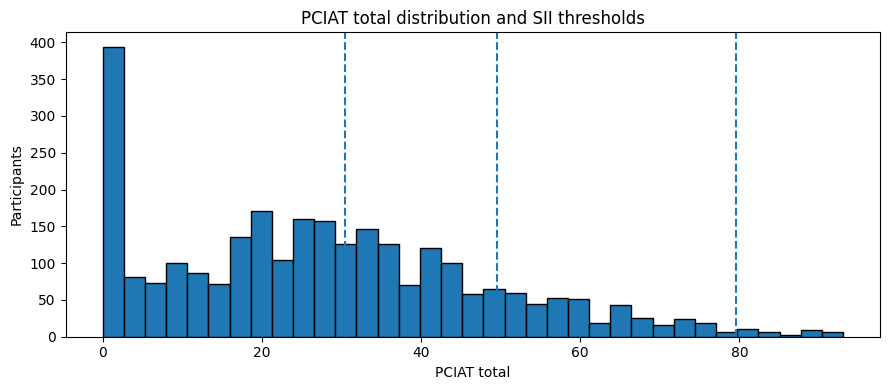

In [31]:
plt.figure(figsize=(9, 4))
plt.hist(
    labeled[PCIAT_TOTAL],
    bins=35,
    edgecolor="black",
)

for threshold in [30.5, 49.5, 79.5]:
    plt.axvline(threshold, linestyle="--")

plt.xlabel("PCIAT total")
plt.ylabel("Participants")
plt.title("PCIAT total distribution and SII thresholds")
plt.tight_layout()
plt.show()


### Leakage implication

Все `PCIAT-*` поля нужно исключить из model features:

1. `PCIAT-PCIAT_Total` непосредственно определяет `sii`;
2. отдельные `PCIAT-PCIAT_01 ... PCIAT-PCIAT_20` являются компонентами этого total score;
3. PCIAT-поля отсутствуют в supplied test schema.

Их можно использовать в EDA только для проверки корректности формирования target.


In [32]:
pciat_cols = [c for c in train.columns if c.startswith("PCIAT")]

print("PCIAT columns in train:", len(pciat_cols))
print("PCIAT columns in test:", len(set(pciat_cols) & set(test.columns)))

assert len(set(pciat_cols) & set(test.columns)) == 0


PCIAT columns in train: 22
PCIAT columns in test: 0


## 7. SII and age

In [33]:
age_by_sii = (
    labeled
    .groupby(TARGET)[AGE_COL]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(2)
)

display(age_by_sii)


,count,mean,median,std,min,max
sii,,,,,,
0.0,1594,9.25,9.0,3.13,5,21
1.0,730,11.12,11.0,3.30,5,22
2.0,378,12.29,12.0,3.28,5,21
3.0,34,14.68,14.0,2.38,11,21


In [34]:
age_sii_counts = pd.crosstab(
    labeled[AGE_COL],
    labeled[TARGET],
)

age_sii_percent = pd.crosstab(
    labeled[AGE_COL],
    labeled[TARGET],
    normalize="index",
) * 100

age_sii_counts.columns = age_sii_counts.columns.astype(int)
age_sii_percent.columns = age_sii_percent.columns.astype(int)

print("Counts by age:")
display(age_sii_counts)

print("SII distribution within each age, %:")
display(age_sii_percent.round(1))


Counts by age:


sii,0,1,2,3
Basic_Demos-Age,,,,
5,69,9,2,0
6,224,37,10,0
7,234,56,18,0
8,254,67,20,0
9,226,84,32,0
10,168,96,41,0
11,104,77,31,2
12,84,72,49,4
13,52,59,37,7


SII distribution within each age, %:


sii,0,1,2,3
Basic_Demos-Age,,,,
5,86.2,11.2,2.5,0.0
6,82.7,13.7,3.7,0.0
7,76.0,18.2,5.8,0.0
8,74.5,19.6,5.9,0.0
9,66.1,24.6,9.4,0.0
10,55.1,31.5,13.4,0.0
11,48.6,36.0,14.5,0.9
12,40.2,34.4,23.4,1.9
13,33.5,38.1,23.9,4.5


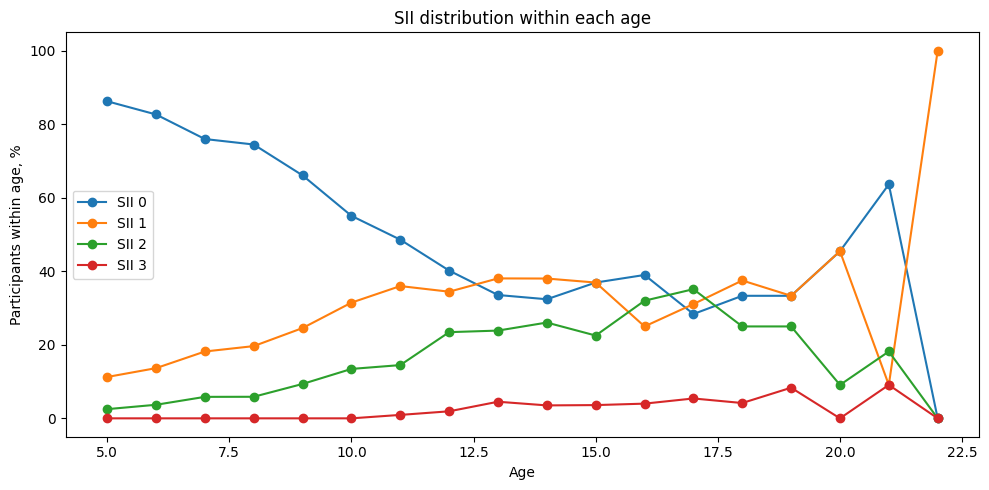

In [35]:
plt.figure(figsize=(10, 5))

for cls in age_sii_percent.columns:
    plt.plot(
        age_sii_percent.index,
        age_sii_percent[cls],
        marker="o",
        label=f"SII {cls}",
    )

plt.xlabel("Age")
plt.ylabel("Participants within age, %")
plt.title("SII distribution within each age")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

В исходном labeled subset возраст заметно связан с распределением `sii`: средний возраст последовательно увеличивается от класса 0 к классу 3.

При этом для старших возрастов выборка намного меньше. Поэтому проценты по отдельным возрастам нужно всегда читать вместе с `age_sii_counts`, особенно для редкого класса 3.

Возраст далее следует рассматривать как важный потенциальный confounder при анализе физических, фитнес- и поведенческих признаков.


## 8. SII and sex

In [36]:
sex_labels = {
    0: "Male",
    1: "Female",
}

sex_sii_counts = pd.crosstab(
    labeled[SEX_COL].map(sex_labels),
    labeled[TARGET],
)

sex_sii_percent = pd.crosstab(
    labeled[SEX_COL].map(sex_labels),
    labeled[TARGET],
    normalize="index",
) * 100

sex_sii_counts.columns = sex_sii_counts.columns.astype(int)
sex_sii_percent.columns = sex_sii_percent.columns.astype(int)

print("Counts:")
display(sex_sii_counts)

print("SII distribution within sex, %:")
display(sex_sii_percent.round(2))


Counts:


sii,0,1,2,3
Basic_Demos-Sex,,,,
Female,638,249,102,8
Male,956,481,276,26


SII distribution within sex, %:


sii,0,1,2,3
Basic_Demos-Sex,,,,
Female,63.99,24.97,10.23,0.8
Male,54.97,27.66,15.87,1.5


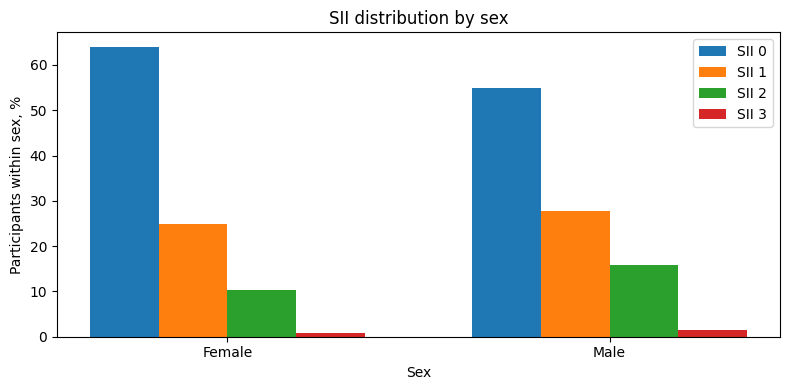

In [37]:
sex_plot = sex_sii_percent.copy()

x = np.arange(len(sex_plot.index))
width = 0.18

plt.figure(figsize=(8, 4))

for i, cls in enumerate(sex_plot.columns):
    plt.bar(
        x + (i - (len(sex_plot.columns) - 1) / 2) * width,
        sex_plot[cls],
        width=width,
        label=f"SII {cls}",
    )

plt.xticks(x, sex_plot.index)
plt.xlabel("Sex")
plt.ylabel("Participants within sex, %")
plt.title("SII distribution by sex")
plt.legend()
plt.tight_layout()
plt.show()


### Interpretation

В этой выборке распределения `sii` для male и female participants различаются, но этот результат нельзя интерпретировать изолированно от возраста и других covariates.

На данном этапе это EDA observation, а не вывод о причинной связи пола с problematic internet use.


## 9. Compact target summary

In [38]:
target_summary = {
    "total_train_rows": len(train),
    "labeled_rows": len(labeled),
    "unlabeled_rows": len(unlabeled),
    "labeled_fraction": len(labeled) / len(train),
    "n_classes": labeled[TARGET].nunique(),
    "majority_class": int(majority_class),
    "minority_class": int(minority_class),
    "majority_minority_ratio": majority_count / minority_count,
    "pciat_sii_mismatches": int(mismatch_mask.sum()),
}

display(
    pd.Series(target_summary, name="value").to_frame()
)


,value
total_train_rows,3960.000000
labeled_rows,2736.000000
unlabeled_rows,1224.000000
labeled_fraction,0.690909
n_classes,4.000000
majority_class,0.000000
minority_class,3.000000
majority_minority_ratio,46.882353
pciat_sii_mismatches,0.000000


## 10. Main findings to carry forward

Для исходного competition train:

1. Supervised subset содержит **2736** участников из 3960.
2. `sii` отсутствует у **1224** участников и его availability полностью совпадает с availability `PCIAT-PCIAT_Total`.
3. Распределение labeled target:
   - `0`: **1594** (58.26%);
   - `1`: **730** (26.68%);
   - `2`: **378** (13.82%);
   - `3`: **34** (1.24%).
4. Класс `3` крайне редкий; отношение размеров class 0 / class 3 составляет примерно **46.9×**.
5. Пороговая реконструкция `PCIAT-PCIAT_Total → sii` даёт **0 mismatches**.
6. Все `PCIAT-*` являются target-related/leakage columns и должны быть исключены из model features.
7. Возраст явно связан с распределением target и должен учитываться при интерпретации последующего EDA.
8. Для пола также наблюдаются различия в class proportions, но их нельзя интерпретировать как независимый эффект без учёта остальных факторов.

